In [1]:
import os
import time
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)


In [2]:
data_dir = "../data/processed"
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

X_train = np.load(os.path.join(data_dir, "X_train.npy"))
X_test = np.load(os.path.join(data_dir, "X_test.npy"))
y_train = np.load(os.path.join(data_dir, "y_train.npy"))
y_test = np.load(os.path.join(data_dir, "y_test.npy"))

artifacts = joblib.load(os.path.join(data_dir, "preprocessing_artifacts.joblib"))
label_encoder = artifacts["label_encoder"]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)
print("\nClasses:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{i} -> {cls}")


X_train shape: (2979959, 47)
X_test shape : (504402, 47)
y_train shape: (2979959,)
y_test shape : (504402,)

Classes:
0 -> BENIGN
1 -> Bot
2 -> DDoS
3 -> DoS GoldenEye
4 -> DoS Hulk
5 -> DoS Slowhttptest
6 -> DoS slowloris
7 -> FTP-Patator
8 -> Heartbleed
9 -> Infiltration
10 -> PortScan
11 -> SSH-Patator
12 -> Web Attack - Brute Force
13 -> Web Attack - Sql Injection
14 -> Web Attack - XSS


In [3]:
train_dist = pd.Series(label_encoder.inverse_transform(y_train)).value_counts()
test_dist = pd.Series(label_encoder.inverse_transform(y_test)).value_counts()

print("Train distribution:")
print(train_dist)
print("\nTest distribution:")
print(test_dist)


Train distribution:
BENIGN                        1643718
DoS Hulk                       134672
DDoS                           101569
PortScan                       100000
DoS GoldenEye                  100000
DoS slowloris                  100000
Bot                            100000
FTP-Patator                    100000
SSH-Patator                    100000
DoS Slowhttptest               100000
Web Attack - Brute Force       100000
Infiltration                   100000
Web Attack - XSS               100000
Web Attack - Sql Injection     100000
Name: count, dtype: int64

Test distribution:
BENIGN                        419227
DoS Hulk                       34569
DDoS                           25603
PortScan                       18164
DoS GoldenEye                   2057
FTP-Patator                     1187
DoS slowloris                   1077
DoS Slowhttptest                1046
SSH-Patator                      644
Bot                              391
Web Attack - Brute Force        

In [4]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        random_state=42,
        n_jobs=None
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

results = []
trained_models = {}

for name, model in models.items():
    print("=" * 80)
    print(f"Training: {name}")

    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Weighted Precision": precision,
        "Weighted Recall": recall,
        "Weighted F1": f1,
        "Training Time (s)": round(end - start, 2)
    })

    trained_models[name] = model

    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall: {recall:.4f}")
    print(f"Weighted F1: {f1:.4f}")
    print(f"Training Time: {end - start:.2f}s")


Training: Random Forest
Accuracy: 0.9978
Weighted Precision: 0.9978
Weighted Recall: 0.9978
Weighted F1: 0.9977
Training Time: 399.88s
Training: Logistic Regression
Accuracy: 0.9635
Weighted Precision: 0.9902
Weighted Recall: 0.9635
Weighted F1: 0.9761
Training Time: 1198.67s
Training: Decision Tree
Accuracy: 0.9980
Weighted Precision: 0.9980
Weighted Recall: 0.9980
Weighted F1: 0.9980
Training Time: 71.04s


In [5]:
results_df = pd.DataFrame(results).sort_values(by="Weighted F1", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Training Time (s)
0,Decision Tree,0.997960,0.997959,0.997960,0.997958,71.04
1,Random Forest,0.997760,0.997826,0.997760,0.997714,399.88
2,Logistic Regression,0.963474,0.990236,0.963474,0.976133,1198.67


In [6]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model selected:", best_model_name)


Best model selected: Decision Tree


In [7]:
y_pred_best = best_model.predict(X_test)

print("Best Model:", best_model_name)
print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


Best Model: Decision Tree

Classification Report:

                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419227
                       Bot       0.84      0.81      0.83       391
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       1.00      0.99      0.99      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.96      0.97      0.96      1046
             DoS slowloris       0.97      0.97      0.97      1077
               FTP-Patator       1.00      1.00      1.00      1187
                Heartbleed       0.00      0.00      0.00         2
              Infiltration       1.00      0.86      0.92         7
                  PortScan       0.99      0.98      0.99     18164
               SSH-Patator       1.00      1.00      1.00       644
  Web Attack - Brute Force       0.72      0.68      0.70       

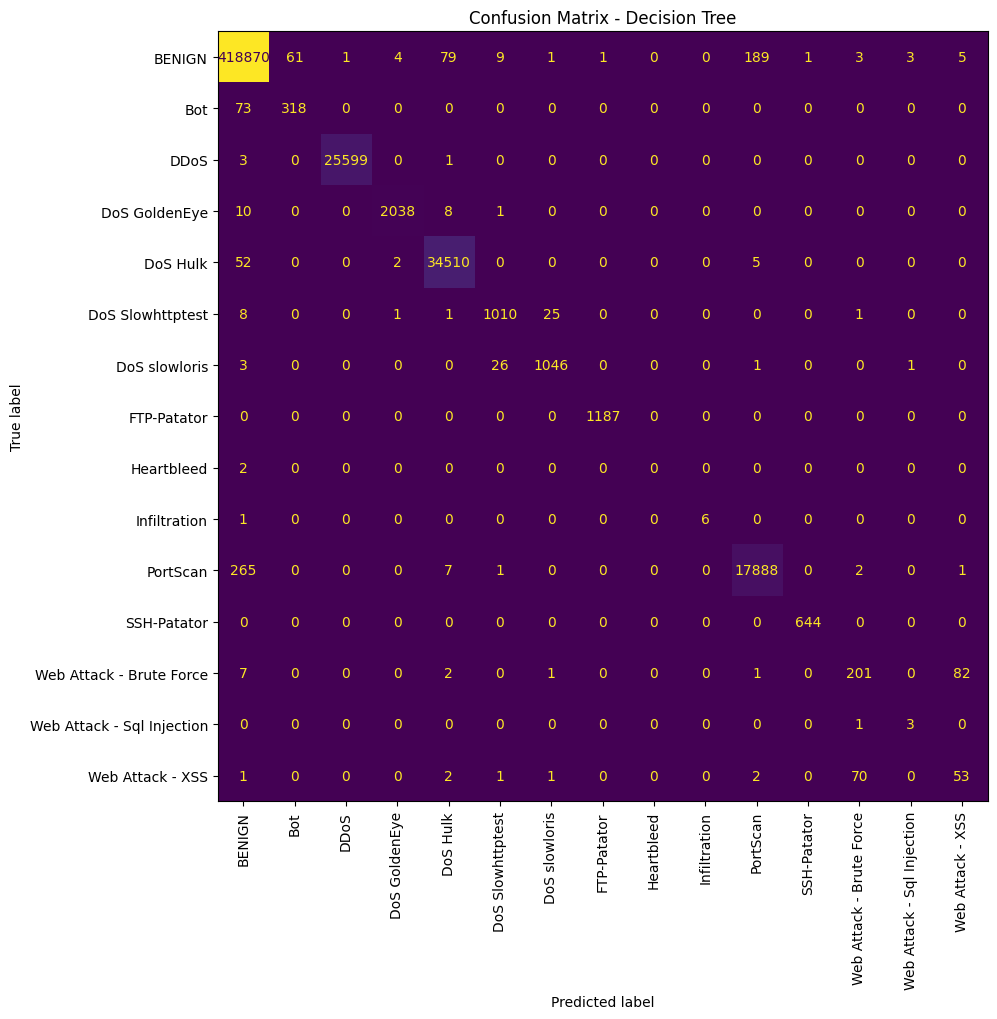

In [8]:
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(14, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


In [9]:
pred_labels = label_encoder.inverse_transform(y_pred_best)
true_labels = label_encoder.inverse_transform(y_test)

examples_df = pd.DataFrame({
    "Actual": true_labels[:20],
    "Predicted": pred_labels[:20]
})

examples_df


,Actual,Predicted
0,BENIGN,BENIGN
1,BENIGN,BENIGN
2,BENIGN,BENIGN
3,BENIGN,BENIGN
4,BENIGN,BENIGN
5,BENIGN,BENIGN
6,FTP-Patator,FTP-Patator
7,DoS Hulk,DoS Hulk
8,DDoS,DDoS
9,BENIGN,BENIGN


,Feature,Importance
0,Destination Port,0.293926
38,Init_Win_bytes_forward,0.206820
41,min_seg_size_forward,0.065288
39,Init_Win_bytes_backward,0.047288
9,Bwd Packet Length Max,0.038842
2,Total Fwd Packets,0.035507
35,ACK Flag Count,0.034698
1,Flow Duration,0.032963
17,Fwd IAT Std,0.032402
18,Fwd IAT Min,0.025454


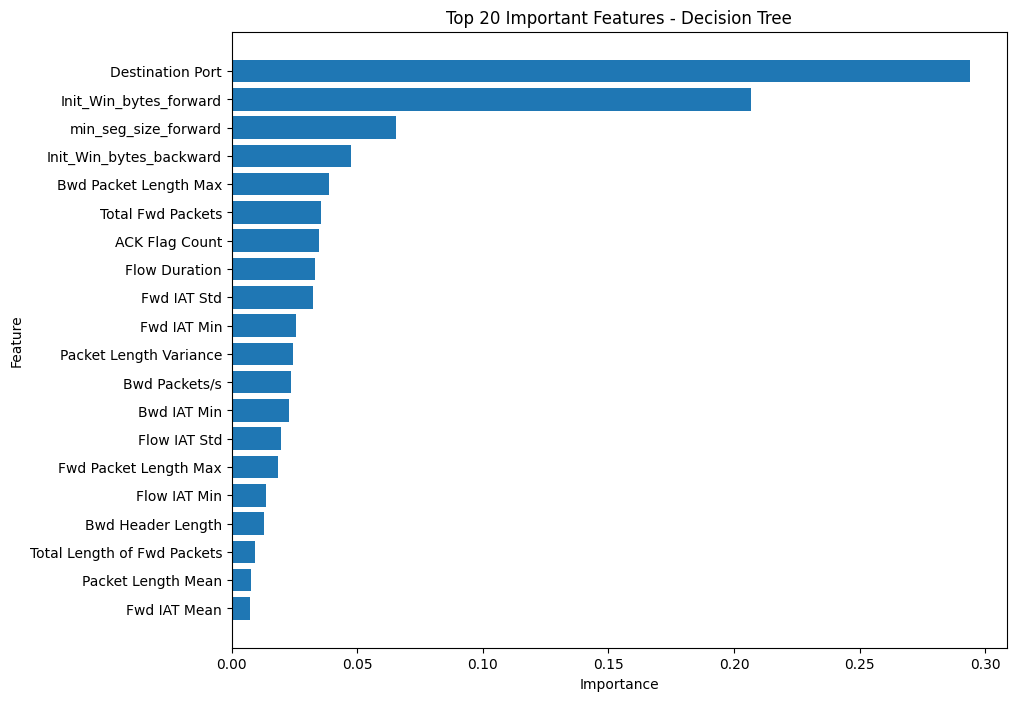

In [10]:
if hasattr(best_model, "feature_importances_"):
    selected_columns = artifacts.get("selected_columns", [f"feature_{i}" for i in range(X_train.shape[1])])

    importance_df = pd.DataFrame({
        "Feature": selected_columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False).head(20)

    display(importance_df)

    plt.figure(figsize=(10, 8))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Top 20 Important Features - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
else:
    print(f"{best_model_name} does not provide feature_importances_.")


In [11]:
best_model_path = os.path.join(models_dir, "best_nids_model.joblib")
joblib.dump(best_model, best_model_path)

model_info = {
    "best_model_name": best_model_name,
    "results_table": results_df.to_dict(orient="records")
}
joblib.dump(model_info, os.path.join(models_dir, "model_info.joblib"))

print("Saved model to:", best_model_path)
print("Saved model info to:", os.path.join(models_dir, "model_info.joblib"))


Saved model to: ../models\best_nids_model.joblib
Saved model info to: ../models\model_info.joblib


In [12]:
sample = X_test[0].reshape(1, -1)
sample_pred = best_model.predict(sample)
sample_label = label_encoder.inverse_transform(sample_pred)[0]
actual_label = label_encoder.inverse_transform([y_test[0]])[0]

print("Actual label   :", actual_label)
print("Predicted label:", sample_label)


Actual label   : BENIGN
Predicted label: BENIGN
